# Lab 3: Adversarial Examples Lab

### Introduction

In this lab, we will explore the concept of adversarial examples as introduced in the seminal paper by Goodfellow et al. (2015): "Explaining and Harnessing Adversarial Examples." Adversarial examples are inputs to machine learning models that have been subtly modified to cause the model to make a mistake, while appearing nearly identical to the original input from a human perspective.

### Objectives

1. Understand why neural networks are vulnerable to adversarial examples
2. Implement the Fast Gradient Sign Method (FGSM) to generate adversarial examples
3. Visualize how small, imperceptible perturbations can lead to high-confidence misclassifications

### Implementation

We'll train a simple deep learning model on the MNIST handwritten digit dataset, then apply FGSM to generate adversarial examples that fool our model.

### Setup Instructions

This notebook requires PyTorch and related libraries. If you encounter issues installing these dependencies locally, you can run this notebook in Google Colab, which provides these libraries pre-installed.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

### Data Loading and Preprocessing

In this section, we set up the data pipeline for our experiment:

1. **Device Configuration**: We determine whether to use GPU (CUDA) or CPU for computation.

2. **Data Transformation**: We apply a simple transformation to convert the MNIST images to PyTorch tensors. Unlike many image classification tasks, we don't normalize the pixel values here because MNIST pixel values are already in the range [0,1] after ToTensor()

3. **Dataset Loading**: We load the MNIST dataset, which consists of 28×28 grayscale images of handwritten digits (0-9).
   - Training set: 60,000 examples
   - Test set: 10,000 examples

4. **DataLoader Creation**: We create DataLoader objects that will feed batches of data to our model during training and evaluation.
   - We use a batch size of 64
   - We shuffle the training data to improve model generalization


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

batch_size = 64

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.24MB/s]


### Display Data

Batch shape: torch.Size([64, 1, 28, 28])
Target shape: torch.Size([64])


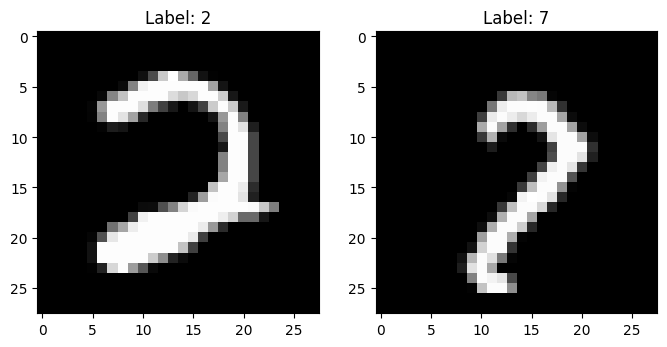

In [3]:
examples = iter(train_loader)
example_data, example_targets = next(examples)

print(f"Batch shape: {example_data.shape}")  # Should be [batch_size, channels, height, width]
print(f"Target shape: {example_targets.shape}")  # Should be [batch_size]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(example_data[0].squeeze(), cmap='gray')
axes[0].set_title(f'Label: {example_targets[0].item()}')
axes[1].imshow(example_data[1].squeeze(), cmap='gray')
axes[1].set_title(f'Label: {example_targets[1].item()}')
plt.show()

### Model Definition

Define a simple neural network for MNIST digit classification.

Implement a neural network architecture of your choice. For simplicity, we recommend starting with a Multi-Layer Perceptron (MLP) with the following structure:
1. An input layer that flattens the 28x28 MNIST images
2. A hidden layer with 64 neurons and ReLU activation
3. An output layer with 10 neurons (one for each digit 0-9)

For implementation, use PyTorch's nn.Module as the base class and implement:
- The `__init__` method to define your network layers
- The `forward` method to define how data flows through your network

For model components, refer to:
- [torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)
- [torch.nn.ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)

<details>
  <summary>Hint 1</summary>
  Remember to flatten the input images in the forward method. MNIST images come in shape [batch_size, 1, 28, 28] and need to be reshaped to [batch_size, 784]. Use x = x.view(x.size(0), -1) for this purpose.
</details>

<details>
  <summary>Hint 2</summary>
  When creating your first linear layer, the input size should be 784 (28×28×1) to match the flattened MNIST images.
</details>

In [14]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self, x):
      X = self.flatten(x)
      logits = self.linear_relu_stack(X)
      return logits



model = Net().to(device)

### Training the Neural Network

Below is a basic training loop for our MNIST classifier. We use CrossEntropyLoss as our loss function, which is the standard choice for multi-class classification problems. For optimization, we employ SGD (Stochastic Gradient Descent).

The training process consists of:
1. Forward pass through the network
2. Loss calculation
3. Gradient computation via backpropagation
4. Parameter updates using the optimizer

In [6]:
learning_rate = 1e-2

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

num_epochs = 10

model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)           # Step 1: Get predictions
        loss = criterion(outputs, labels) # Step 2: Measure error
        # Backward pass and optimize
        optimizer.zero_grad()             # Step 3: Clear old gradients
        loss.backward()                   # Step 4: Compute new gradients
        optimizer.step()                  # Step 5: Update model weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 1.2724
Epoch [2/10], Loss: 0.4951
Epoch [3/10], Loss: 0.3918
Epoch [4/10], Loss: 0.3505
Epoch [5/10], Loss: 0.3259
Epoch [6/10], Loss: 0.3080
Epoch [7/10], Loss: 0.2941
Epoch [8/10], Loss: 0.2817
Epoch [9/10], Loss: 0.2710
Epoch [10/10], Loss: 0.2612


### Model Evaluation
We evaluate our model's performance by measuring accuracy on the test dataset. This is a simplified approach - in a real environment, we would typically use a separate validation dataset and employ more comprehensive evaluation metrics. However, for the purposes of this notebook, this straightforward evaluation is sufficient to demonstrate the model's baseline performance before we explore adversarial examples.

We’re testing on ‘clean’ images (no tricks yet). A simple MLP should get ~90% accuracy — good, but not perfect.

In [7]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

clean_acc = 100 * correct / total
print(f"Accuracy on clean test images: {clean_acc:.2f}% (expect ~90%)")

Accuracy on clean test images: 92.94% (expect ~90%)


### Comparing Optimizer Performance

For a challenge, try training with Adam, and Adagrad. Plot their losses. Which converges fastest?

In [23]:
adamModel = Net()
learning_rate = 1e-2

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 10
adam_history = []

adamModel.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)           # Step 1: Get predictions
        loss = criterion(outputs, labels) # Step 2: Measure error
        # Backward pass and optimize
        optimizer.zero_grad()             # Step 3: Clear old gradients
        loss.backward()                   # Step 4: Compute new gradients
        optimizer.step()                  # Step 5: Update model weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    adam_history.append(running_loss)


Epoch [1/10], Loss: 0.0784
Epoch [2/10], Loss: 0.0716
Epoch [3/10], Loss: 0.0684
Epoch [4/10], Loss: 0.0696
Epoch [5/10], Loss: 0.0654
Epoch [6/10], Loss: 0.0668
Epoch [7/10], Loss: 0.0543
Epoch [8/10], Loss: 0.0578
Epoch [9/10], Loss: 0.0613
Epoch [10/10], Loss: 0.0557


In [24]:
model = Net()
learning_rate = 1e-2

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adagrad(model.parameters(), lr=learning_rate)

num_epochs = 10
adagrad_history = []

model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)           # Step 1: Get predictions
        loss = criterion(outputs, labels) # Step 2: Measure error
        # Backward pass and optimize
        optimizer.zero_grad()             # Step 3: Clear old gradients
        loss.backward()                   # Step 4: Compute new gradients
        optimizer.step()                  # Step 5: Update model weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    adagrad_history.append(running_loss)

Epoch [1/10], Loss: 0.3529
Epoch [2/10], Loss: 0.2473
Epoch [3/10], Loss: 0.2176
Epoch [4/10], Loss: 0.1986
Epoch [5/10], Loss: 0.1850
Epoch [6/10], Loss: 0.1746
Epoch [7/10], Loss: 0.1663
Epoch [8/10], Loss: 0.1593
Epoch [9/10], Loss: 0.1534
Epoch [10/10], Loss: 0.1481


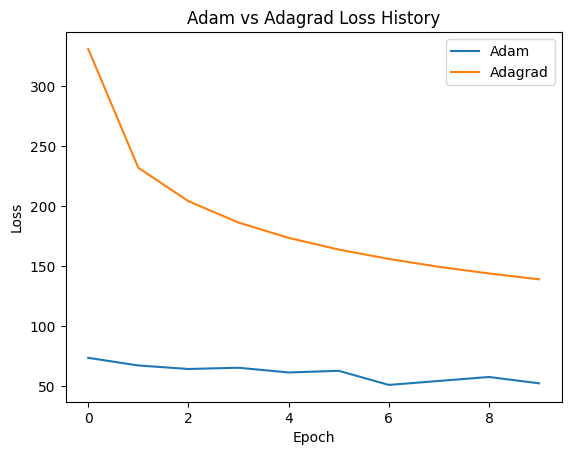

In [25]:
plt.plot(adam_history)
plt.plot(adagrad_history)
plt.title("Adam vs Adagrad Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Adam", "Adagrad"])
plt.show()

### FGSM Attack
Implement FGSM attack.

In [28]:
default_epsilon = 0.15

def fgsm_attack(
    model: nn.Module, images: torch.Tensor, labels: torch.Tensor, epsilon: float = default_epsilon
) -> torch.Tensor:
    """
    Creates adversarial examples via the FGSM method:
    x_adv = x + epsilon * sign( dJ/dx ).
    """
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    # Ensure gradients are being tracked
    images.requires_grad = True

    # TODO:
    # 1. Calculate outputs and loss
    # 2. Backpropagate loss (use backward method)
    # 3. Collect the element-wise sign of the data gradient (you can access it by images.grad.data.sign())
    # 4. Create the perturbed image
    # 5. Clamp to [0,1] if needed to ensure valid pixel range

   # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    # Zero previous gradients
    model.zero_grad()

    # Backward pass to get gradients
    loss.backward()

    # Get sign of gradients
    sign_data_grad = images.grad.data.sign()

    # Create adversarial example
    with torch.no_grad():
        perturbed_images = images + epsilon * sign_data_grad
        perturbed_images = torch.clamp(perturbed_images, 0, 1)

    return perturbed_images

### Calculate accuracy for adversarial examples

In [29]:
correct = 0
total = 0
for images, labels in test_loader:
    # Generate adversarial images
    adv_images = fgsm_attack(model, images, labels, default_epsilon)

    # Re-classify
    outputs = model(adv_images.to(device))
    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted.cpu() == labels).sum().item()

adv_acc = 100 * correct / total
print(f"Accuracy on adversarial test images (FGSM, eps={default_epsilon}): {adv_acc:.2f}%")

Accuracy on adversarial test images (FGSM, eps=0.15): 1.02%


### Display adversarial examples

Let's compare original and adversarial images side-by-side.

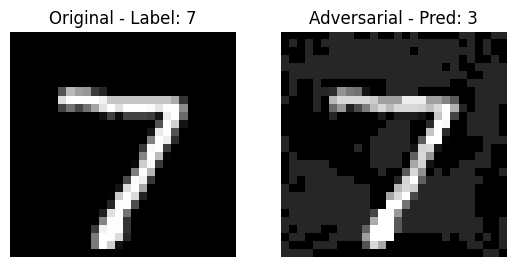

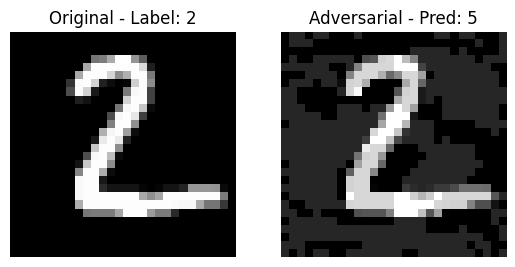

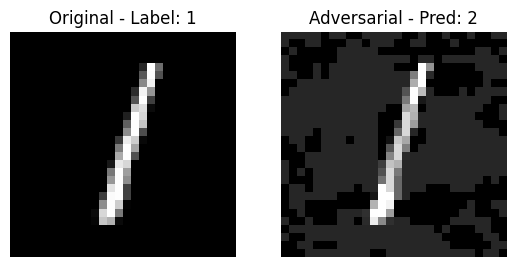

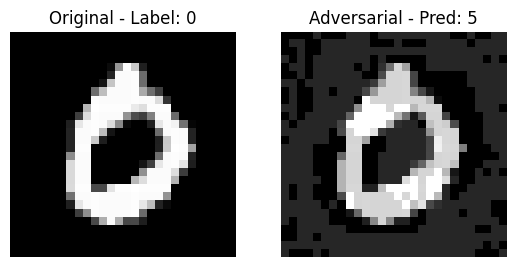

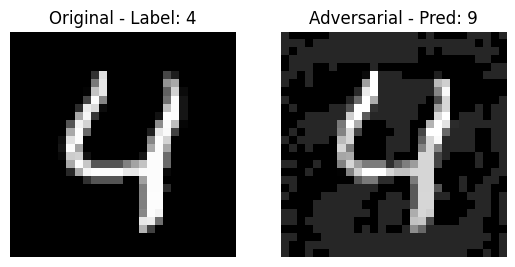

In [30]:
examples = iter(test_loader)
example_images, example_labels = next(examples)
example_images = example_images[:5]
example_labels = example_labels[:5]

adv_ex = fgsm_attack(model, example_images, example_labels, default_epsilon)

for i in range(5):
    plt.figure()

    plt.subplot(1, 2, 1)
    plt.title(f"Original - Label: {example_labels[i].item()}")
    plt.imshow(example_images[i][0].cpu(), cmap="gray")
    plt.axis("off")

    adv_label_out = model(adv_ex[i].unsqueeze(0))
    _, adv_pred = torch.max(adv_label_out, 1)
    plt.subplot(1, 2, 2)
    plt.title(f"Adversarial - Pred: {adv_pred.item()}")
    plt.imshow(adv_ex[i][0].detach().cpu(), cmap="gray")
    plt.axis("off")

    plt.show()

### Epsilon Parameter Analysis
 In this section, you'll analyze how the epsilon parameter affects the effectiveness of adversarial examples. The epsilon parameter controls the magnitude of the perturbation applied to the original images.

**Task:**
1. Evaluate the model's accuracy on adversarial examples generated with different epsilon values (try at least 5 different values)
2. Create a line plot showing model accuracy (y-axis) vs. epsilon value (x-axis)
3. Discuss the trade-off between:
- Visual perceptibility of the perturbations (higher epsilon = more visible changes)
- Attack success rate (higher epsilon = more successful attacks = lower model accuracy)

In [53]:
epsilons = [0, .05, .1, .15, .2, .25, .3]
accuracies = []

def test(model, loader, epsilon):
  correct = 0
  total = 0
  for images, labels in loader:
      adv_images = fgsm_attack(model, images, labels, epsilon)

      outputs = model(adv_images.to(device))
      _, predicted = torch.max(outputs.data, 1)

      total += labels.size(0)
      correct += (predicted.cpu() == labels).sum().item()

  adv_acc = 100 * correct / total
  print(f"Accuracy on adversarial test images (FGSM, eps={epsilon}): {adv_acc:.2f}%")
  return adv_acc


for eps in epsilons:
  acc = test(model, test_loader, eps)
  accuracies.append(acc)

Accuracy on adversarial test images (FGSM, eps=0): 95.48%
Accuracy on adversarial test images (FGSM, eps=0.05): 58.34%
Accuracy on adversarial test images (FGSM, eps=0.1): 10.85%
Accuracy on adversarial test images (FGSM, eps=0.15): 1.02%
Accuracy on adversarial test images (FGSM, eps=0.2): 0.04%
Accuracy on adversarial test images (FGSM, eps=0.25): 0.00%
Accuracy on adversarial test images (FGSM, eps=0.3): 0.00%


Text(0, 0.5, 'Accuracy')

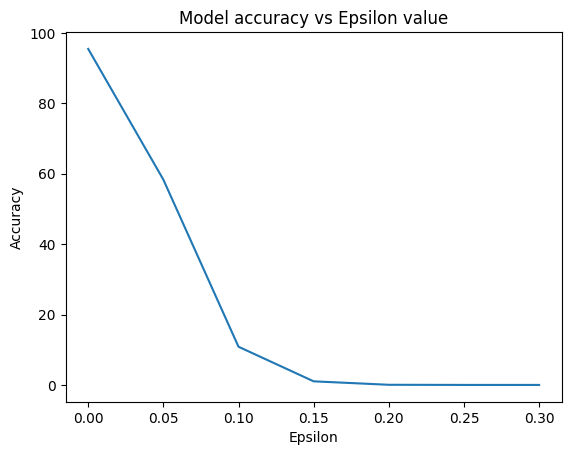

In [42]:
plt.plot(epsilons,accuracies)
plt.title("Model accuracy vs Epsilon value")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")

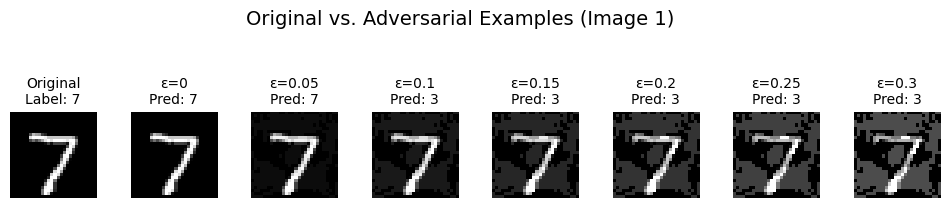

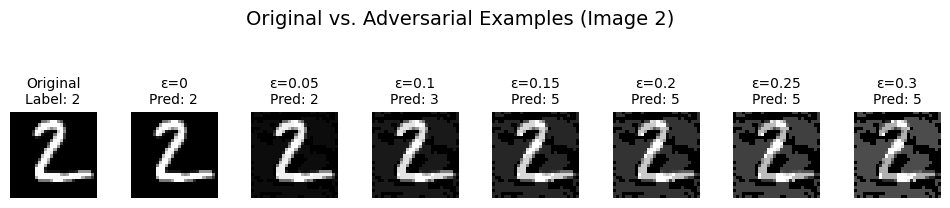

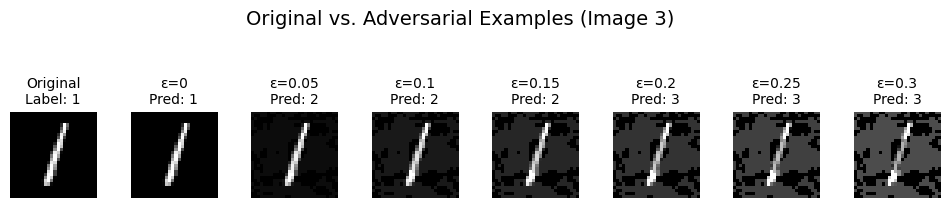

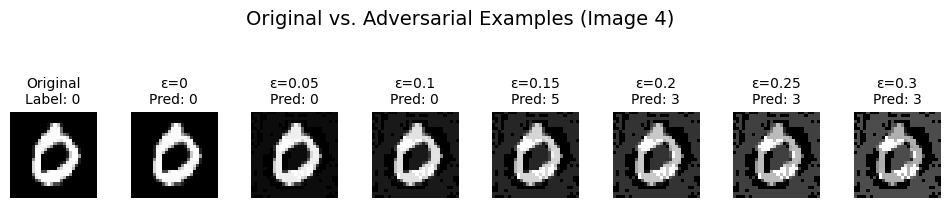

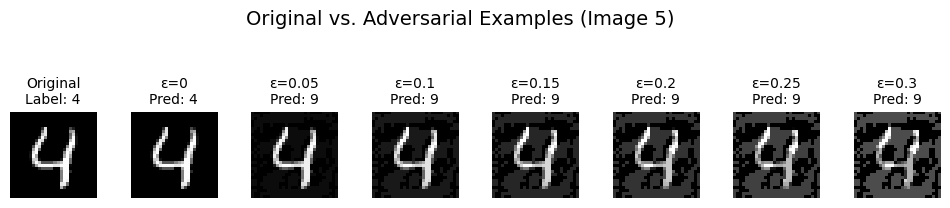

In [52]:
stored_adv_examples = {}

examples = iter(test_loader)
example_images, example_labels = next(examples)
example_images, example_labels = example_images[:5], example_labels[:5]

for eps in epsilons:
    adv_ex = fgsm_attack(model, example_images, example_labels, epsilon=eps)
    stored_adv_examples[eps] = adv_ex.clone().detach()

for i in range(5):
    fig, axes = plt.subplots(1, len(epsilons) + 1, figsize=(12, 3))
    fig.suptitle(f"Original vs. Adversarial Examples (Image {i+1})", fontsize=14)

    axes[0].imshow(example_images[i][0].cpu(), cmap="gray")
    axes[0].set_title(f"Original\nLabel: {example_labels[i].item()}", fontsize=10)
    axes[0].axis("off")

    for idx, eps in enumerate(epsilons):
        adv_ex = stored_adv_examples[eps]
        adv_label_out = model(adv_ex[i].unsqueeze(0))
        _, adv_pred = torch.max(adv_label_out, 1)

        axes[idx + 1].imshow(adv_ex[i][0].cpu(), cmap="gray")
        axes[idx + 1].set_title(f"ε={eps}\nPred: {adv_pred.item()}", fontsize=10)
        axes[idx + 1].axis("off")

    plt.subplots_adjust(wspace=0.4)
    plt.show()



Trade-offs between :
* Visual perceptibility of the perturbations (higher epsilon = more visible changes)
   -   When ε is small (e.g., 0.05), the added noise is subtle, making it difficult to notice.
   - With ε between 0.1 and 0.2, perturbations may start to become visible as slight distortions in textures or edges.
   - At high ε values (e.g. 0.2+), images appear severely altered


* Attack success rate (higher epsilon = more successful attacks = lower model accuracy)
   - A small ε ( < 0.05) might not be enough to push the image across the decision boundary, meaning the model still classifies correctly.
   - A moderate ε (~0.1) is often effective in causing misclassification while keeping perturbations less perceptible.
   - A high ε ( > 0.2) completely disrupts the image, making attacks nearly 100% successful but also making it obvious that the image is corrupted.


In my opinion ε between (0.0, 0.1) would be the best choice, depending on the scale of the attack, but for example in real-world cases even choosing ε of 0.05 and downgrading accuracy from 95% to just 58% is huge and the change in images may persist undiscovered. To be honest even smaller ε might be preferred